# Second-Order Nonlinear SVR for the Duffing Equation (Quantum Kernel)

$$\frac{d^2 f}{dx^2} = c\cos(ex) - a f - b f^3,\qquad a{=}0.5,\ b{=}0.15,\ c{=}3,\ e{=}3\pi,$$
with $f(0)=1$, $f'(0)=1$.

## Derivation

**Model.** $f(x)=w^\dagger\varphi(x)+b$, so $f'(x)=w^\dagger\varphi'(x)$ and $f''(x)=w^\dagger\varphi''(x)$.

**Primal.** With $g(x,y)=c\cos(ex)-ay-by^3$ and dummy variables $y_i\approx f(x_i)$ to absorb the cubic nonlinearity:
$$\min_{w,b,e,\xi}\ \tfrac12 w^\dagger w+\tfrac{\gamma}{2}e^\top e+\tfrac{\gamma}{2}\xi^\top\xi$$
subject to
$$w^\dagger\varphi''(x_i)-g(x_i,y_i)=e_i,\quad w^\dagger\varphi(x_0)+b=f_0,\quad w^\dagger\varphi'(x_0)=f'_0,\quad y_i=w^\dagger\varphi(x_i)+b+\xi_i.$$

**Lagrange multipliers** $\alpha_i$ (DE), $\beta$ (value IC), $\delta$ (slope IC), $\eta_i$ (dummy). The KKT stationarity conditions give
$$w=\sum_i\alpha_i\varphi''(x_i)+\beta\,\varphi(x_0)+\delta\,\varphi'(x_0)+\sum_i\eta_i\varphi(x_i),\qquad \beta+\sum_i\eta_i=0,$$
$$e_i=-\alpha_i/\gamma,\quad \xi_i=\eta_i/\gamma,\quad \eta_i=\alpha_i\big(a+3b\,y_i^2\big).$$

**Kernel trick.** With $\kappa(u,v)=\varphi(u)^\dagger\varphi(v)$ and $D^{[q,p]}(u,v)=\partial_u^{\,q}\partial_v^{\,p}\kappa(u,v)$, every $\varphi^{(q)}(u)^\dagger\varphi^{(p)}(v)$ becomes $D^{[q,p]}(u,v)$. Substituting $w$ leaves a **nonlinear system** in $(\alpha,y,\delta,b)$ (with $\eta,\beta$ derived above):
$$
\begin{aligned}
&w^\dagger\varphi''(x_i)-g(x_i,y_i)+\alpha_i/\gamma=0,\\
&w^\dagger\varphi(x_0)+b-f_0=0,\\
&w^\dagger\varphi'(x_0)-f'_0=0,\\
&y_i-\big(w^\dagger\varphi(x_i)+b+\eta_i/\gamma\big)=0,
\end{aligned}
$$
where each $w^\dagger\varphi^{(p)}(z)=\sum_j\alpha_j D^{[2,p]}(x_j,z)+\beta D^{[0,p]}(x_0,z)+\delta D^{[1,p]}(x_0,z)+\sum_j\eta_j D^{[0,p]}(x_j,z)$.

Because the kernel terms $D^{[q,p]}$ depend only on the grid, they are computed **once**; the nonlinearity lives only in $g$ and $\eta_i(\alpha,y,b)$. The system is solved by least squares (random restarts, as the paper does).

**Solution.** $\displaystyle f(x)=\sum_j\alpha_j D^{[2,0]}(x_j,x)+\beta D^{[0,0]}(x_0,x)+\delta D^{[1,0]}(x_0,x)+\sum_j\eta_j D^{[0,0]}(x_j,x)+b.$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [2]:
# ============================================================
# QUANTUM KERNEL (unchanged architecture, cached statevectors)
# ============================================================
def build_HEA(n_qubits=8, depth=1, seed=1):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, 2*np.pi, size=(depth, n_qubits, 2))
    qc = QuantumCircuit(n_qubits, name="HEA")
    for i in range(depth):
        for q in range(n_qubits):
            qc.rx(theta[i, q, 0], q); qc.rz(theta[i, q, 1], q)
        for q in range(n_qubits-1):
            qc.cx(q, q+1)
    return qc

def build_kernel_feature_map(n_qubits=8):
    x = Parameter("x")
    qc = QuantumCircuit(n_qubits, name="KernelMap")
    qc.compose(build_HEA(n_qubits, 1, seed=1), inplace=True)
    for q in range(n_qubits): qc.rx((q*x)/2, q)
    qc.compose(build_HEA(n_qubits, 1, seed=2), inplace=True)
    for q in range(n_qubits): qc.rx((q*x)/2, q)
    return qc

N_QUBITS = 8
_QC = build_kernel_feature_map(N_QUBITS)
_PX = [p for p in _QC.parameters if p.name == "x"][0]
_psi_cache = {}
def _psi(x):
    key = round(float(x), 12)
    if key not in _psi_cache:
        _psi_cache[key] = Statevector.from_instruction(_QC.assign_parameters({_PX: x})).data
    return _psi_cache[key]
def kappa(u, v):
    "k(u,v) = |<psi(v)|psi(u)>|^2"
    return np.abs(np.vdot(_psi(v), _psi(u)))**2

print("Kernel ready. kappa(0.3,0.3) =", round(kappa(0.3, 0.3), 6))

Kernel ready. kappa(0.3,0.3) = 1.0


In [3]:
# ============================================================
# GENERIC KERNEL DERIVATIVE  D[q,p](u,v) = d^q/du^q d^p/dv^p kappa
# central finite differences; q,p in {0,1,2}; total order up to 4
# ============================================================
DERIV_H = 2e-3   # stable for the 4th-order term D[2,2] with this smooth kernel

def _stencil(order, h):
    if order == 0: return {0: 1.0}
    if order == 1: return {-1: -1/(2*h), 1: 1/(2*h)}
    if order == 2: return {-1: 1/h**2, 0: -2/h**2, 1: 1/h**2}

def D(q, p, u, v, h=DERIV_H):
    cq, cp = _stencil(q, h), _stencil(p, h)
    s = 0.0
    for a, wa in cq.items():
        for c, wc in cp.items():
            s += wa * wc * kappa(u + a*h, v + c*h)
    return s

# sanity: symmetry  D[2,0](u,v) == D[0,2](v,u)
print("symmetry check:", round(D(2,0,0.4,0.6),5), "==", round(D(0,2,0.6,0.4),5))

symmetry check: 1.28527 == 1.28527


In [4]:
# ============================================================
# DUFFING EQUATION + high-accuracy reference
# ============================================================
a, b, c, e = 0.5, 0.15, 3.0, 3*np.pi
X0, F0, FP0 = 0.0, 1.0, 1.0

def g_fun(x, y):  return c*np.cos(e*x) - a*y - b*y**3   # f'' = g(x,f)
# dg/dy = -a - 3 b y^2  (used implicitly through eta_i = alpha_i (a + 3 b y_i^2))

def _system(x, Y): return [Y[1], g_fun(x, Y[0])]
_ref = solve_ivp(_system, [0, 1], [F0, FP0], dense_output=True, rtol=1e-10, atol=1e-12)
print(f"Duffing: f'' = {c} cos({e:.4f} x) - {a} f - {b} f^3,  f(0)={F0}, f'(0)={FP0}")

Duffing: f'' = 3.0 cos(9.4248 x) - 0.5 f - 0.15 f^3,  f(0)=1.0, f'(0)=1.0


In [5]:
# ============================================================
# SECOND-ORDER NONLINEAR SVR SOLVER
# ============================================================
class DuffingSVRSolver:
    def __init__(self, x_train, gamma=1e5):
        self.X = np.asarray(x_train, float)
        self.N = len(self.X)
        self.gamma = gamma
        self.params = None

    def _precompute(self, x0):
        X, N = self.X, self.N
        # matrices over the grid (independent of the unknowns -> computed once)
        self.M22 = np.array([[D(2,2,X[j],X[i]) for j in range(N)] for i in range(N)])
        self.M02 = np.array([[D(0,2,X[j],X[i]) for j in range(N)] for i in range(N)])
        self.M20 = np.array([[D(2,0,X[j],X[i]) for j in range(N)] for i in range(N)])
        self.M00 = np.array([[D(0,0,X[j],X[i]) for j in range(N)] for i in range(N)])
        # boundary vectors involving x0
        self.v02 = np.array([D(0,2,x0,X[i]) for i in range(N)])
        self.v12 = np.array([D(1,2,x0,X[i]) for i in range(N)])
        self.v00 = np.array([D(0,0,x0,X[i]) for i in range(N)])
        self.v10 = np.array([D(1,0,x0,X[i]) for i in range(N)])
        self.u20 = np.array([D(2,0,X[j],x0) for j in range(N)])
        self.u00 = np.array([D(0,0,X[j],x0) for j in range(N)])
        self.u21 = np.array([D(2,1,X[j],x0) for j in range(N)])
        self.u01 = np.array([D(0,1,X[j],x0) for j in range(N)])
        self.s00, self.s10 = D(0,0,x0,x0), D(1,0,x0,x0)
        self.s01, self.s11 = D(0,1,x0,x0), D(1,1,x0,x0)
        self.x0 = x0

    def _unpack(self, p, aa, bb):
        N = self.N
        alpha, y = p[:N], p[N:2*N]
        delta, bconst = p[2*N], p[2*N+1]
        eta  = alpha * (aa + 3*bb*y**2)     # KKT dL/dy_i
        beta = -np.sum(eta)                  # KKT dL/db
        return alpha, y, delta, bconst, eta, beta

    def _residuals(self, p, aa, bb, cc, ee, x0, f0, fp0):
        alpha, y, delta, bconst, eta, beta = self._unpack(p, aa, bb)
        g = self.gamma
        wpp = self.M22@alpha + beta*self.v02 + delta*self.v12 + self.M02@eta   # f''(x_i)
        R1  = wpp - g_fun(self.X, y) + alpha/g
        w0  = self.u20@alpha + beta*self.s00 + delta*self.s10 + self.u00@eta   # f(x0)
        R2  = np.array([w0 + bconst - f0])
        wp0 = self.u21@alpha + beta*self.s01 + delta*self.s11 + self.u01@eta   # f'(x0)
        R3  = np.array([wp0 - fp0])
        wf  = self.M20@alpha + beta*self.v00 + delta*self.v10 + self.M00@eta   # f(x_i)
        R4  = y - (wf + bconst + eta/g)
        return np.concatenate([R1, R2, R3, R4])

    def fit(self, aa, bb, cc, ee, x0, f0, fp0, n_restarts=8, seed=0):
        self._precompute(x0)
        N = self.N
        rng = np.random.default_rng(seed)
        best = None
        for t in range(n_restarts):
            p0 = np.zeros(2*N+2)
            p0[N:2*N] = f0 + 0.1*rng.standard_normal(N)   # y near f0
            p0[:N]    = 0.01*rng.standard_normal(N)
            p0[2*N+1] = f0
            out = least_squares(self._residuals, p0, method="lm",
                                args=(aa,bb,cc,ee,x0,f0,fp0), max_nfev=20000)
            if best is None or out.cost < best.cost:
                best = out
            if out.cost < 1e-12:
                break
        self.params = best.x
        self._aa, self._bb = aa, bb
        print(f"Converged: {best.success} | final cost: {best.cost:.3e} | "
              f"function evals: {best.nfev}")
        return self

    def predict(self, x_eval):
        X, N = self.X, self.N
        alpha, y, delta, bconst, eta, beta = self._unpack(self.params, self._aa, self._bb)
        out = []
        for x in np.atleast_1d(np.asarray(x_eval, float)):
            val = (sum(alpha[j]*D(2,0,X[j],x) for j in range(N))
                   + beta*D(0,0,self.x0,x) + delta*D(1,0,self.x0,x)
                   + sum(eta[j]*D(0,0,X[j],x) for j in range(N)) + bconst)
            out.append(val)
        return np.array(out)

print("SVR solver defined.")

SVR solver defined.


In [6]:
# ============================================================
# SOLVE
# ============================================================
x_train = np.linspace(0, 1, 13)
x_test  = np.linspace(0, 1, 200)

solver = DuffingSVRSolver(x_train, gamma=1e5)
solver.fit(a, b, c, e, X0, F0, FP0, n_restarts=8)

f_pred = solver.predict(x_test)
f_ref  = _ref.sol(x_test)[0]
err = np.abs(f_pred - f_ref); rng = f_ref.max() - f_ref.min()
print(f"\nf_pred(0) = {f_pred[0]:.6f}  (target {F0})")
print(f"max abs error      = {err.max():.4e}")
print(f"mean abs error     = {err.mean():.4e}")
print(f"max normalized err = {err.max()/rng:.4e}")

Converged: True | final cost: 5.097e-24 | function evals: 9

f_pred(0) = 1.000000  (target 1.0)
max abs error      = 4.2179e-04
mean abs error     = 2.3650e-04
max normalized err = 7.3204e-04


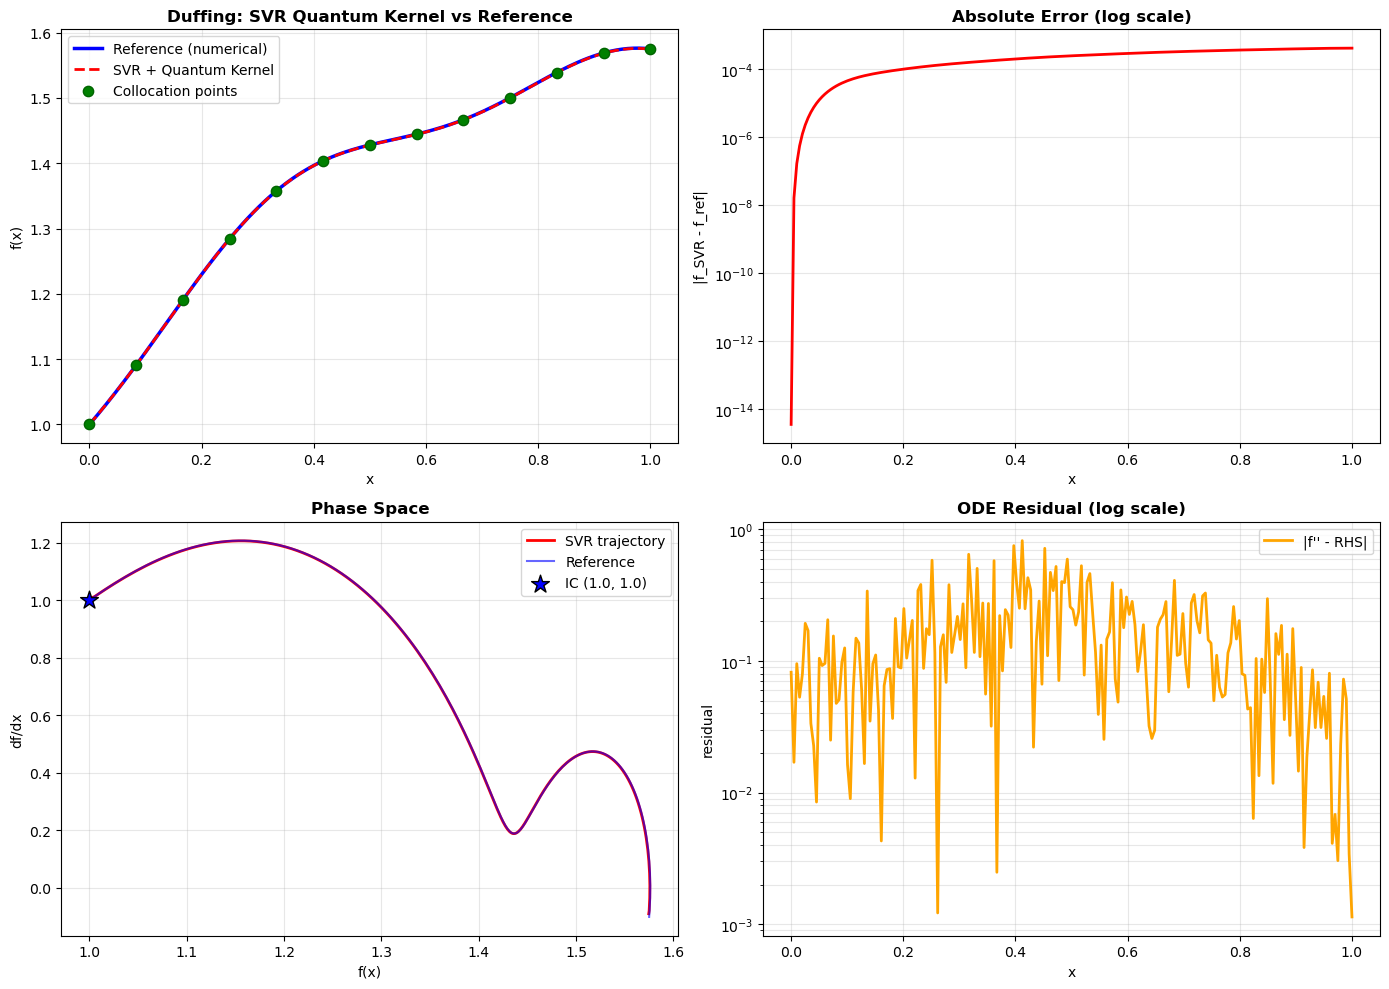

In [7]:
# ============================================================
# PLOTS
# ============================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].plot(x_test, f_ref, "b-", lw=2.5, label="Reference (numerical)")
ax[0,0].plot(x_test, f_pred, "r--", lw=2, label="SVR + Quantum Kernel")
ax[0,0].scatter(x_train, solver.predict(x_train), color="green", s=55,
                zorder=5, edgecolors="darkgreen", label="Collocation points")
ax[0,0].set_xlabel("x"); ax[0,0].set_ylabel("f(x)")
ax[0,0].set_title("Duffing: SVR Quantum Kernel vs Reference", fontweight="bold")
ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

ax[0,1].semilogy(x_test, err, "r-", lw=2)
ax[0,1].set_xlabel("x"); ax[0,1].set_ylabel("|f_SVR - f_ref|")
ax[0,1].set_title("Absolute Error (log scale)", fontweight="bold")
ax[0,1].grid(alpha=0.3, which="both")

fp_pred = np.gradient(f_pred, x_test)
ax[1,0].plot(f_pred, fp_pred, "r-", lw=2, label="SVR trajectory")
ax[1,0].plot(f_ref, _ref.sol(x_test)[1], "b-", lw=1.5, alpha=0.6, label="Reference")
ax[1,0].scatter([F0], [FP0], color="blue", s=180, marker="*", zorder=6,
                edgecolors="k", label=f"IC ({F0}, {FP0})")
ax[1,0].set_xlabel("f(x)"); ax[1,0].set_ylabel("df/dx")
ax[1,0].set_title("Phase Space", fontweight="bold")
ax[1,0].legend(); ax[1,0].grid(alpha=0.3)

eps = 1e-4
fpp = (solver.predict(x_test+eps) - 2*f_pred + solver.predict(x_test-eps))/eps**2
residual = np.abs(fpp - g_fun(x_test, f_pred))
ax[1,1].semilogy(x_test, residual, color="orange", lw=2, label="|f'' - RHS|")
ax[1,1].set_xlabel("x"); ax[1,1].set_ylabel("residual")
ax[1,1].set_title("ODE Residual (log scale)", fontweight="bold")
ax[1,1].legend(); ax[1,1].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

In [8]:
# ============================================================
# SUMMARY
# ============================================================
print("="*64)
print("DUFFING EQUATION  -  SECOND-ORDER NONLINEAR SVR (QUANTUM KERNEL)")
print("="*64)
print(f"Equation : f'' = {c} cos({e:.4f} x) - {a} f - {b} f^3")
print(f"ICs      : f(0)={F0}, f'(0)={FP0}")
print(f"Kernel   : 2x(HEA depth-1 + feature map), {N_QUBITS} qubits")
print(f"Training : {len(x_train)} collocation points, gamma={solver.gamma:.0e}")
print("-"*64)
print(f"f_pred(0)            = {f_pred[0]:.6f}  (target {F0})")
print(f"max absolute error   = {err.max():.4e}")
print(f"mean absolute error  = {err.mean():.4e}")
print(f"max normalized error = {err.max()/rng:.4e}")
print(f"max ODE residual     = {residual.max():.4e}")
print("="*64)

DUFFING EQUATION  -  SECOND-ORDER NONLINEAR SVR (QUANTUM KERNEL)
Equation : f'' = 3.0 cos(9.4248 x) - 0.5 f - 0.15 f^3
ICs      : f(0)=1.0, f'(0)=1.0
Kernel   : 2x(HEA depth-1 + feature map), 8 qubits
Training : 13 collocation points, gamma=1e+05
----------------------------------------------------------------
f_pred(0)            = 1.000000  (target 1.0)
max absolute error   = 4.2179e-04
mean absolute error  = 2.3650e-04
max normalized error = 7.3204e-04
max ODE residual     = 8.2003e-01
